# Use KG and CLIP to improve recall for BDD100K is predicted by YOLOE

In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 691.1 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 54.2 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 re

# 1. Installation and Imports

In [2]:
# 1. Installation and Imports
import json, copy
from pathlib import Path
from collections import Counter
from PIL import Image

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yaml, numpy as np
from tqdm.auto import tqdm
from ultralytics import YOLO, YOLOE

import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import torch.nn.functional as F
import torchvision

from transformers import CLIPProcessor, CLIPModel

print("All imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
All imports successful
PyTorch version: 2.10.0+cu128
CUDA available: True


# 2. Configuration

In [3]:
# 2. Configuration
PATH_DATASET = Path("/kaggle/input/datasets/quckhnh123/bdd100k-subset")
PATH_KG = Path("/kaggle/input/datasets/quckhnh123/kg-ad-v3/KG.json")
IMAGE_DIR = PATH_DATASET / "images"
LABEL_DIR = PATH_DATASET / "labels"
DATA_YAML = PATH_DATASET / "data.yaml"

YOLOE_MODEL_PATH = "yoloe-26m-seg.pt"
YOLOWORLD_MODEL_PATH = "yolov8m-worldv2.pt"

DEVICE = 0
IMGSZ = 640
MAX_IMAGES_TEST = None        

PRED_CONF = 0.01               
EVAL_CONF_THR = 0.25          
IOU_THR = 0.50

LOW_CONF_THRES = 0.3
ALPHA = 0.75
IOU_NMS = 0.7

USEFUL_RELATIONS = {"isa", "atlocation"}

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print("Configuration loaded successfully")
print(f"  Dataset: {PATH_DATASET}")
print(f"  Images: {MAX_IMAGES_TEST or 'All'}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Configuration loaded successfully
  Dataset: /kaggle/input/datasets/quckhnh123/bdd100k-subset
  Images: All


# 3. Dataset Loading and Exploration

In [4]:
# 3. Dataset Loading and Exploration
def load_classes_from_yaml(data_yaml_path):
    with open(data_yaml_path, "r") as f:
        data = yaml.safe_load(f)
    names = data["names"]
    if isinstance(names, dict):
        names = [names[k] for k in sorted(names.keys(), key=lambda x: int(x))]
    return [str(x) for x in names]

def load_image_paths(image_dir, max_images=None, seed=42):
    image_dir = Path(image_dir)
    image_paths = []
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        image_paths.extend(image_dir.glob(ext))
    return sorted(str(p) for p in image_paths)

def yolo_to_xyxy(xc, yc, bw, bh, w, h):
    x1 = (xc - bw/2) * w
    y1 = (yc - bh/2) * h
    x2 = (xc + bw/2) * w
    y2 = (yc + bh/2) * h
    return [float(x1), float(y1), float(x2), float(y2)]
    
def build_gt(image_paths, labels_dir, target_classes):
    gt = {}
    shapes = {}
    class_counts = Counter()
    for img_path in tqdm(image_paths, desc="Building Ground Truth"):
        try:
            with Image.open(img_path) as img:
                w, h = img.size 
        except Exception:
            continue
            
        shapes[img_path] = (w, h)
        label_path = Path(labels_dir) / (Path(img_path).stem + ".txt")
        boxes = []
        if label_path.exists():
            with open(label_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_id = int(float(parts[0]))
                    if cls_id < 0 or cls_id >= len(target_classes):
                        continue
                    xc, yc, bw, bh = map(float, parts[1:5])
                    boxes.append({
                        "class_id": cls_id,
                        "class_name": target_classes[cls_id],
                        "bbox": yolo_to_xyxy(xc, yc, bw, bh, w, h)
                    })
                    class_counts[target_classes[cls_id]] += 1
        gt[img_path] = boxes
    return gt, shapes, class_counts

TARGET_CLASSES = load_classes_from_yaml(DATA_YAML)
image_paths = load_image_paths(IMAGE_DIR, max_images=MAX_IMAGES_TEST)
GT, IMAGE_SHAPES, CLASS_COUNTS = build_gt(image_paths, LABEL_DIR, TARGET_CLASSES)

print(f"\n Dataset Statistics:")
print(f"  - Total images: {len(image_paths)}")
print(f"  - Total annotations: {sum(len(v) for v in GT.values()):,}")
print(f"  - Classes: {len(TARGET_CLASSES)}")
print(f"  - Average objects per image: {sum(len(v) for v in GT.values())/len(GT):.2f}")

Building Ground Truth:   0%|          | 0/10000 [00:00<?, ?it/s]


 Dataset Statistics:
  - Total images: 10000
  - Total annotations: 190,888
  - Classes: 10
  - Average objects per image: 19.09


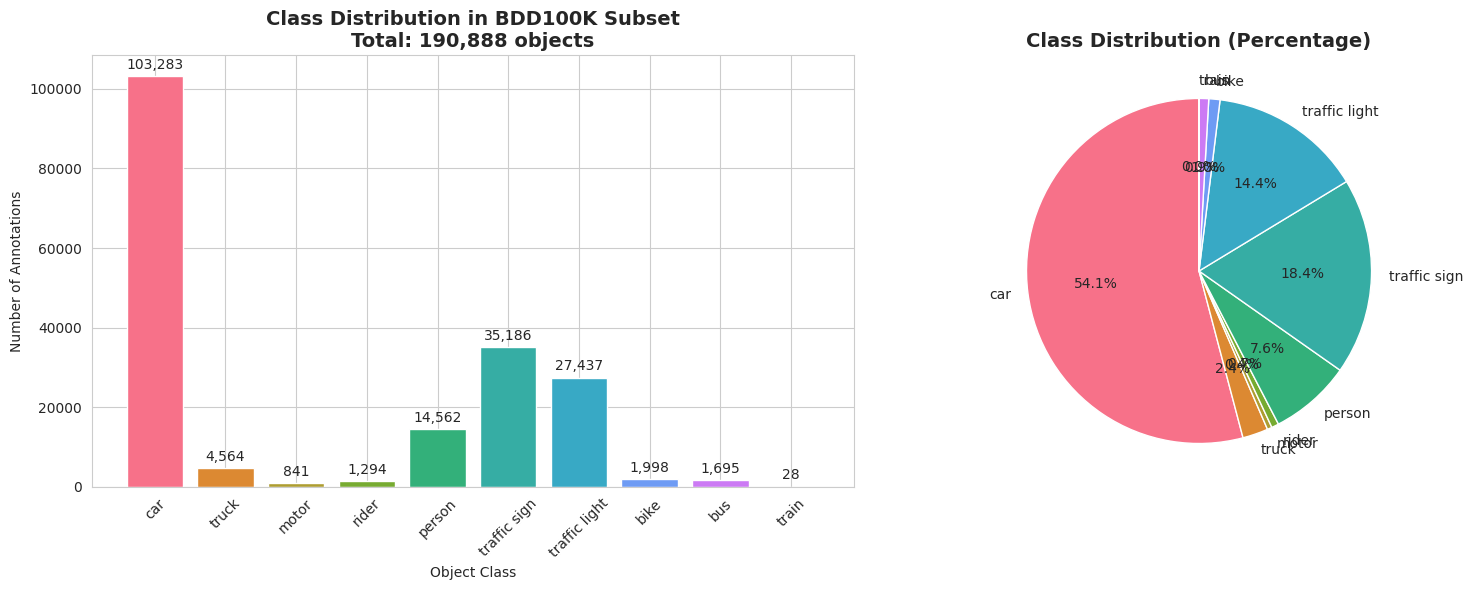


 Class Imbalance Analysis:
  car            : 103,283 ( 54.1%)
  traffic sign   : 35,186 ( 18.4%)
  traffic light  : 27,437 ( 14.4%)
  person         : 14,562 (  7.6%)
  truck          :  4,564 (  2.4%)
  bike           :  1,998 (  1.0%)
  bus            :  1,695 (  0.9%)
  rider          :  1,294 (  0.7%)
  motor          :    841 (  0.4%)
  train          :     28 (  0.0%)


In [5]:
# Exploratory Data Analysis - Visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

classes = list(CLASS_COUNTS.keys())
counts = list(CLASS_COUNTS.values())
colors = sns.color_palette("husl", len(classes))

bars = axes[0].bar(classes, counts, color=colors)
axes[0].set_title(f"Class Distribution in BDD100K Subset\nTotal: {sum(counts):,} objects", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Object Class")
axes[0].set_ylabel("Number of Annotations")
axes[0].tick_params(axis='x', rotation=45)

for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                f'{count:,}', ha='center', va='bottom', fontsize=10)

axes[1].pie(counts, labels=classes, autopct='%1.1f%%', startangle=90, colors=colors)
axes[1].set_title("Class Distribution (Percentage)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n Class Imbalance Analysis:")
for cls, count in sorted(CLASS_COUNTS.items(), key=lambda x: x[1], reverse=True):
    pct = (count / sum(CLASS_COUNTS.values())) * 100
    print(f"  {cls:15s}: {count:6,d} ({pct:5.1f}%)")

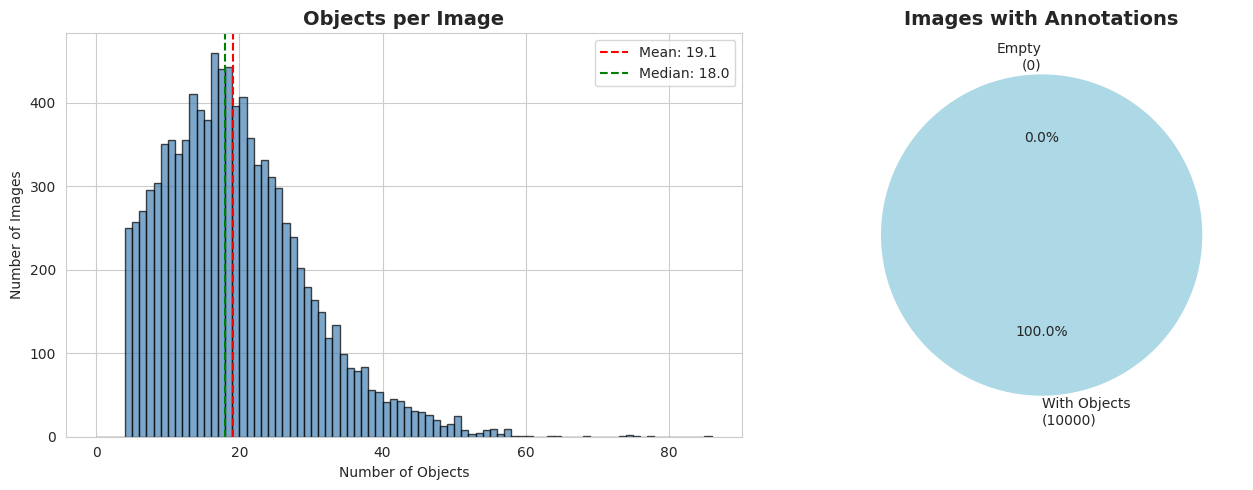


 Image Statistics:
  Images with annotations: 10,000 (100.0%)
  Images without annotations: 0 (0.0%)
  Mean objects per image: 19.09
  Max objects per image: 85


In [6]:
# Image-level statistics
images_with_boxes = sum(1 for boxes in GT.values() if len(boxes) > 0)
objects_per_image = [len(boxes) for boxes in GT.values()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(objects_per_image, bins=range(0, max(objects_per_image)+2, 1), 
             color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_title("Objects per Image", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Number of Objects")
axes[0].set_ylabel("Number of Images")
axes[0].axvline(np.mean(objects_per_image), color='red', linestyle='--', label=f'Mean: {np.mean(objects_per_image):.1f}')
axes[0].axvline(np.median(objects_per_image), color='green', linestyle='--', label=f'Median: {np.median(objects_per_image):.1f}')
axes[0].legend()

empty_images = sum(1 for n in objects_per_image if n == 0)
axes[1].pie([empty_images, len(objects_per_image)-empty_images], 
            labels=[f'Empty\n({empty_images})', f'With Objects\n({len(objects_per_image)-empty_images})'],
            autopct='%1.1f%%', colors=['lightcoral', 'lightblue'], startangle=90)
axes[1].set_title("Images with Annotations", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("image_statistics.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Image Statistics:")
print(f"  Images with annotations: {images_with_boxes:,} ({images_with_boxes/len(GT)*100:.1f}%)")
print(f"  Images without annotations: {empty_images:,} ({empty_images/len(GT)*100:.1f}%)")
print(f"  Mean objects per image: {np.mean(objects_per_image):.2f}")
print(f"  Max objects per image: {max(objects_per_image)}")

# 4. Load ConceptNet + build concept sets

In [7]:
# 4. Load ConceptNet + build concept sets
def normalize_name(x):
    return str(x).lower().replace("_", " ").replace("-", " ").strip()

def clean_concept_uri(x):
    x = str(x).lower().strip()
    for w in ["a ", "an ", "the "]:
        x = x.replace(w, "")
    return normalize_name(x)

def clean_relation(x):
    m = {"AtLocation":"atlocation", "IsA":"isa"}
    return m.get(x, x.lower().strip())

def is_noisy_concept(text, max_words=5):
    t = normalize_name(text)
    return len(t)<=1 or '/' in t or len(t.split())>max_words

def load_conceptnet_json(path):
    with open(path, "r", encoding="utf-8") as f:
        kg = json.load(f)
    graph = {}
    total_triples = 0
    for cls, relations in kg.items():
        cls = normalize_name(cls)
        graph[cls] = {}
        for relation, objects in relations.items():
            relation = clean_relation(relation)
            if relation not in USEFUL_RELATIONS:
                continue
            concepts = { clean_concept_uri(obj) for obj in objects if not is_noisy_concept(obj) }
            graph[cls][relation] = concepts
            total_triples += len(concepts)

    print(f"Loaded {total_triples} triples from KG JSON")
    return graph

def build_class_concepts(target_classes, graph, top_k=30):
    class_concepts = {}

    for cls in target_classes:
        cls_clean = normalize_name(cls)
        relations = graph.get(cls_clean, {})

        class_concepts[cls] = {}

        for relation, concepts in relations.items():
            class_concepts[cls][relation] = set(list(concepts)[:top_k])
            
    return class_concepts

conceptnet_df = load_conceptnet_json(PATH_KG)
CLASS_CONCEPTS = build_class_concepts(TARGET_CLASSES, conceptnet_df, top_k=30)

print(f"\n Knowledge Graph Statistics:")
print(f"  Total triples: {len(conceptnet_df)}")
print(f"  Classes with concepts: {sum(1 for c in CLASS_CONCEPTS if CLASS_CONCEPTS[c])}")
for cls, concepts in CLASS_CONCEPTS.items():
    total_concepts_for_class = sum(len(concept_set) for concept_set in concepts.values())
    print(f"  {cls:15s}: {total_concepts_for_class} concepts")

Loaded 155 triples from KG JSON

 Knowledge Graph Statistics:
  Total triples: 24
  Classes with concepts: 10
  person         : 8 concepts
  rider          : 7 concepts
  car            : 13 concepts
  bus            : 9 concepts
  truck          : 7 concepts
  bike           : 5 concepts
  motor          : 4 concepts
  traffic light  : 5 concepts
  traffic sign   : 5 concepts
  train          : 3 concepts


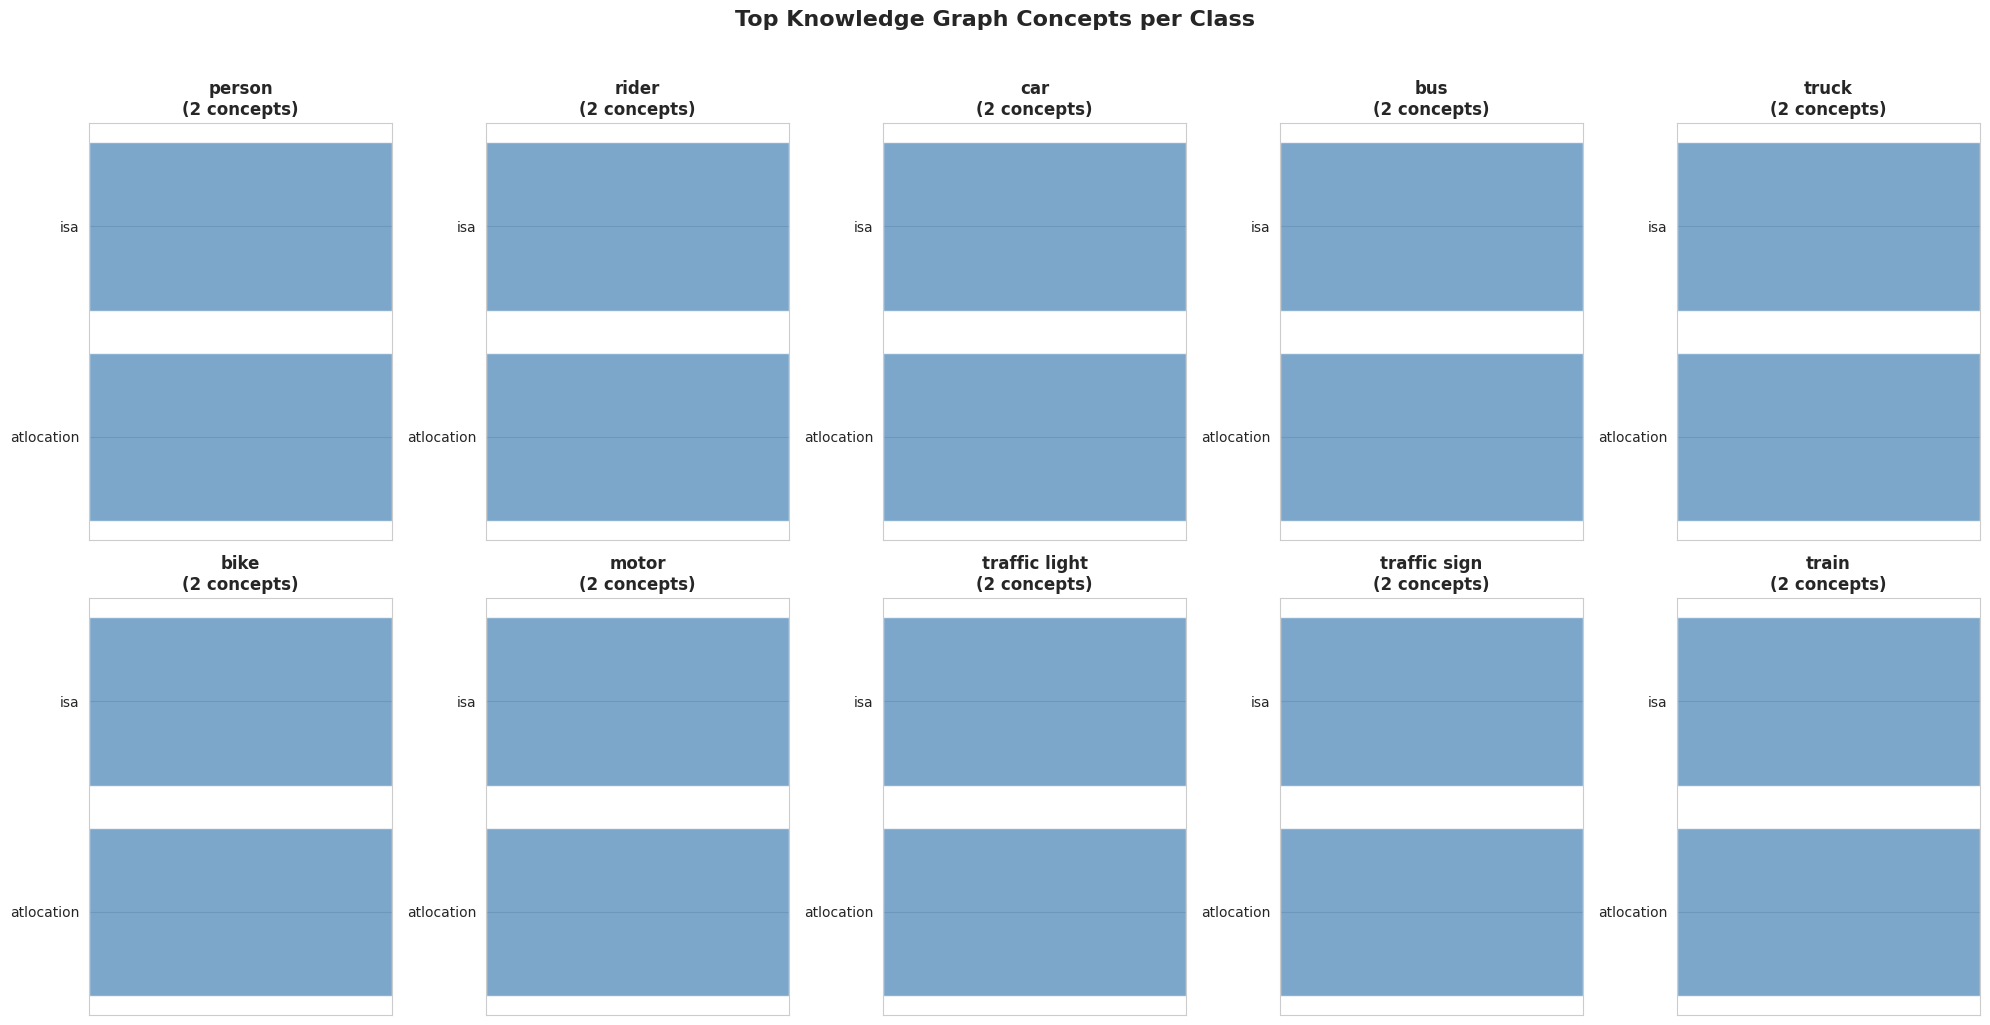


 Concept Overlap:
  Total unique concepts: 2
  Average concepts per class: 2.0


In [8]:
# Visualize Knowledge Graph Concepts
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, (cls, concepts) in enumerate(CLASS_CONCEPTS.items()):
    concept_list = list(concepts)[:10]
    axes[idx].barh(concept_list, [1]*len(concept_list), color='steelblue', alpha=0.7)
    axes[idx].set_title(f"{cls}\n({len(concepts)} concepts)", fontsize=12, fontweight='bold')
    axes[idx].set_xlim(0, 1)
    axes[idx].set_xticks([])
    axes[idx].set_xlabel("")

plt.suptitle("Top Knowledge Graph Concepts per Class", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("kg_concepts.png", dpi=300, bbox_inches='tight')
plt.show()

all_concepts = set()
for concepts in CLASS_CONCEPTS.values():
    all_concepts.update(concepts)

print(f"\n Concept Overlap:")
print(f"  Total unique concepts: {len(all_concepts)}")
print(f"  Average concepts per class: {np.mean([len(c) for c in CLASS_CONCEPTS.values()]):.1f}")

# 5. Evaluation Functions

In [9]:
# 5. Evaluation Functions
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter + 1e-9
    return inter / union

def compute_map_torchmetrics(preds_dict, gt_dict):
    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")
    preds = []
    targets = []
    all_imgs = sorted(gt_dict.keys())

    for img_path in all_imgs:
        pred_boxes, pred_scores, pred_labels = [], [], []
        for p in preds_dict.get(img_path, []):
            pred_boxes.append(p["bbox"])
            pred_scores.append(p["conf"])
            pred_labels.append(p["class_id"])

        gt_boxes, gt_labels = [], []
        for g in gt_dict.get(img_path, []):
            gt_boxes.append(g["bbox"])
            gt_labels.append(g["class_id"])

        preds.append({
            "boxes": torch.tensor(pred_boxes, dtype=torch.float32).reshape(-1,4),
            "scores": torch.tensor(pred_scores, dtype=torch.float32),
            "labels": torch.tensor(pred_labels, dtype=torch.int64)
        })
        targets.append({
            "boxes": torch.tensor(gt_boxes, dtype=torch.float32).reshape(-1,4),
            "labels": torch.tensor(gt_labels, dtype=torch.int64)
        })

    metric.update(preds, targets)
    result = metric.compute()
    return {"map50": float(result["map_50"]), "map50_95": float(result["map"])}

def evaluate(preds_dict, gt_dict, target_classes, conf_thr=0.25, iou_thr=0.5):
    per_class = {c: {"tp":0,"fp":0,"fn":0} for c in target_classes}
    for img_path, gt_boxes in gt_dict.items():
        preds = [p for p in preds_dict.get(img_path, []) if p["conf"] >= conf_thr]
        preds = sorted(preds, key=lambda x: x["conf"], reverse=True)
        matched = set()
        for p in preds:
            best_iou, best_idx = 0.0, -1
            for i,g in enumerate(gt_boxes):
                if i in matched or p["class_id"] != g["class_id"]:
                    continue
                iou = compute_iou(p["bbox"], g["bbox"])
                if iou > best_iou:
                    best_iou, best_idx = iou, i
            if best_iou >= iou_thr and best_idx >= 0:
                per_class[p["class_name"]]["tp"] += 1
                matched.add(best_idx)
            else:
                per_class[p["class_name"]]["fp"] += 1
        for i,g in enumerate(gt_boxes):
            if i not in matched:
                per_class[g["class_name"]]["fn"] += 1

    rows, total_tp, total_fp, total_fn = [], 0, 0, 0
    for cls in target_classes:
        tp, fp, fn = per_class[cls]["tp"], per_class[cls]["fp"], per_class[cls]["fn"]
        p = tp/(tp+fp+1e-9)
        r = tp/(tp+fn+1e-9)
        f = 2*p*r/(p+r+1e-9)
        rows.append({"class_name":cls, "tp":tp, "fp":fp, "fn":fn, "precision":p, "recall":r, "f1":f})
        total_tp += tp; total_fp += fp; total_fn += fn

    p_all = total_tp/(total_tp+total_fp+1e-9)
    r_all = total_tp/(total_tp+total_fn+1e-9)
    f_all = 2*p_all*r_all/(p_all+r_all+1e-9)
    map_result = compute_map_torchmetrics(preds_dict, gt_dict)
    
    summary = {
        "precision": p_all, "recall": r_all, "f1": f_all,
        "map50": map_result["map50"], "map50_95": map_result["map50_95"],
        "total_tp": total_tp, "total_fp": total_fp, "total_fn": total_fn
    }
    return summary, pd.DataFrame(rows)

# 6. Prediction Utilities

In [10]:
# 6. Prediction Utilities
def load_yoloe_with_prompts(path, target_classes):
    model = YOLOE(path)
    prompts = [c.replace("_", " ") for c in target_classes]
    model.set_classes(prompts)
    return model

def load_yoloworld(path, target_classes):
    model = YOLO(path)
    prompts = [c.replace("_", " ") for c in target_classes]
    model.set_classes(prompts)
    return model

def predict_model(model, image_paths, target_classes, conf=0.03, imgsz=640, device=0, an=False):
    all_preds = {} 
    for img in tqdm(image_paths, desc="Predicting"):
        results = model.predict(source=img, conf=conf, imgsz=imgsz, device=device, verbose=False, agnostic_nms=an)
        preds = []
        for r in results:
            if r.boxes is None:
                continue
            boxes = r.boxes.xyxy.cpu().numpy()
            scores = r.boxes.conf.cpu().numpy()
            clses = r.boxes.cls.cpu().numpy().astype(int)
            for box, score, cls_id in zip(boxes, scores, clses):
                if 0 <= cls_id < len(target_classes):
                    preds.append({
                        "image": img,
                        "class_id": int(cls_id),
                        "class_name": target_classes[cls_id],
                        "conf": float(score),
                        "bbox": [float(x) for x in box]
                    })
        all_preds[img] = preds
    return all_preds

# 7. Baseline: YOLOE

In [11]:
# 7. Baseline: YOLOE
model_yoloe = load_yoloe_with_prompts(YOLOE_MODEL_PATH, TARGET_CLASSES)

pred_yoloe = predict_model(model_yoloe, image_paths, TARGET_CLASSES, conf=PRED_CONF, imgsz=IMGSZ, device=DEVICE, an=False)

summary_yoloe, per_class_yoloe = evaluate(pred_yoloe, GT, TARGET_CLASSES, conf_thr=EVAL_CONF_THR, iou_thr=IOU_THR)
print(summary_yoloe)

requirements: Ultralytics requirement ['git+https://github.com/ultralytics/CLIP.git'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 36 packages in 1.25s
Prepared 2 packages in 2.78s
Installed 2 packages in 2ms
 + clip==1.0 (from git+https://github.com/ultralytics/CLIP.git@488e81a6711eea7346872b46ea928b367da8889d)
 + ftfy==6.3.1

requirements: AutoUpdate success ✅ 4.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



Predicting:   0%|          | 0/10000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


{'precision': 0.8017317126748041, 'recall': 0.22943820460165004, 'f1': 0.3567751181798867, 'map50': 0.30336564779281616, 'map50_95': 0.16966204345226288, 'total_tp': 43797, 'total_fp': 10831, 'total_fn': 147091}


## 8. Baseline: YOLO-World

In [12]:
# 8. Baseline: YOLO-World
model_yoloworld = load_yoloworld(YOLOWORLD_MODEL_PATH, TARGET_CLASSES)

pred_yoloworld = predict_model(model_yoloworld, image_paths, TARGET_CLASSES, conf=PRED_CONF, imgsz=IMGSZ, device=DEVICE, an=False)

summary_yoloworld, per_class_yoloworld = evaluate(pred_yoloworld, GT, TARGET_CLASSES, conf_thr=EVAL_CONF_THR, iou_thr=IOU_THR)
print(summary_yoloworld)

100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 84.1MiB/s]


Predicting:   0%|          | 0/10000 [00:00<?, ?it/s]

{'precision': 0.8455853990295624, 'recall': 0.2181960102258905, 'f1': 0.3468820917432879, 'map50': 0.2712448537349701, 'map50_95': 0.16360241174697876, 'total_tp': 41651, 'total_fp': 7606, 'total_fn': 149237}


# 9. Proposed Method: Knowledge Graph + CLIP

In [13]:
# 9. Proposed Method: KG + CLIP Optimization
def build_global_prompts(class_concepts):
    prompt_map = {}
    all_prompts = []

    for cls, relations in class_concepts.items():
        prompts = []
        
        for concept in relations.get("isa", set()):
            prompt = f"a photo of {concept}"
            prompts.append(prompt)
            all_prompts.append(prompt)
            
        for concept in relations.get("atlocation", set()):
            prompt = f"a photo of {cls} in {concept}"
            prompts.append(prompt)
            all_prompts.append(prompt)
            
        prompt_map[cls] = prompts

    return prompt_map, all_prompts

def clip_kg_optimize(all_preds,class_concepts,low_conf_thr=0.45,alpha=0.5):
    prompt_map, all_prompts = build_global_prompts(class_concepts)
    unique_prompts = list(dict.fromkeys(all_prompts))
    
    text_inputs = clip_processor(
        text=unique_prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(DEVICE)
    with torch.no_grad():
        text_outputs = clip_model.get_text_features(**text_inputs)

        if hasattr(text_outputs, 'pooler_output'):
            text_features = text_outputs.pooler_output
        else:
            text_features = text_outputs

        text_features = F.normalize(text_features, dim=-1)

    new_preds = {}

    for img_path, preds in tqdm(all_preds.items(), desc="CLIP Processing"):
        local_preds = copy.deepcopy(preds)
        image = Image.open(img_path).convert("RGB")

        image_inputs = clip_processor(
            images=image,
            return_tensors="pt",
        ).to(DEVICE)

        with torch.no_grad():
            image_outputs = clip_model.get_image_features(**image_inputs)
            
            if hasattr(image_outputs, 'pooler_output'):
                image_features = image_outputs.pooler_output
            else:
                image_features = image_outputs
            image_features = F.normalize(image_features, dim=-1)

            similarity = image_features @ text_features.T 

            probs = similarity.squeeze(0).cpu().numpy()

        prompt_scores = dict(zip(unique_prompts, probs))

        class_prior = {}
        for cls, prompts in prompt_map.items():
            if len(prompts) == 0:
                class_prior[cls] = 0.0
                continue
            scores = [prompt_scores.get(p, 0.0) for p in prompts]
            class_prior[cls] = sum(scores) / len(prompts)

        values = np.array(list(class_prior.values()))
        if len(values) > 1 and values.max() > values.min() + 1e-8:
            min_v = values.min()
            max_v = values.max()
            for cls in class_prior:
                class_prior[cls] = (class_prior[cls] - min_v) / (max_v - min_v + 1e-8)

        for p in local_preds:
            cls = p["class_name"]
            conf = float(p["conf"])
            prior = class_prior.get(cls, 0.0)

            p["clip_prior"] = prior
            p["fused"] = False

            if conf < low_conf_thr:
                fused = (conf ** alpha) * (prior ** (1 - alpha))
                if fused > conf:
                    p["conf"] = min(fused, 1.0)
                    p["fused"] = True

        new_preds[img_path] = local_preds

    return new_preds

In [14]:
def apply_nms(preds_dict, iou_thr=0.5):
    new_preds = {}

    for img_path, preds in preds_dict.items():

        if len(preds) == 0:
            new_preds[img_path] = []
            continue

        kept_preds = []

        class_ids = sorted(set(p["class_id"] for p in preds))

        for cls in class_ids:

            cls_preds = [p for p in preds if p["class_id"] == cls]

            boxes = torch.tensor(
                [p["bbox"] for p in cls_preds],
                dtype=torch.float32
            )

            scores = torch.tensor(
                [p["conf"] for p in cls_preds],
                dtype=torch.float32
            )

            keep = torchvision.ops.nms(
                boxes,
                scores,
                iou_thr
            )

            for idx in keep.tolist():
                kept_preds.append(cls_preds[idx])

        new_preds[img_path] = kept_preds

    return new_preds

In [15]:
summaries_kg = []
per_class_list = [] 

for i in range(3):
    print(f"\n--- Iteration {i+1}/3: CLIP+KG ---")
    pred_kg = clip_kg_optimize(pred_yoloe, CLASS_CONCEPTS, low_conf_thr=LOW_CONF_THRES, alpha=ALPHA)
    pred_kg_nms = apply_nms(
        pred_kg,
        iou_thr=IOU_NMS      
    )
    summary_kg, per_class_kg = evaluate(pred_kg_nms, GT, TARGET_CLASSES, conf_thr=EVAL_CONF_THR, iou_thr=IOU_THR)
    print(summary_kg)
    summaries_kg.append(summary_kg)
    per_class_list.append(per_class_kg)

avg_summary_kg_clip = {}
std_summary_kg = {}
for key in summaries_kg[0].keys():
    values = [s[key] for s in summaries_kg]
    avg_summary_kg_clip[key] = np.mean(values)
    std_summary_kg[key] = np.std(values)

avg_per_class_kg_clip = pd.DataFrame({"class_name": TARGET_CLASSES})
for col in ["tp", "fp", "fn","recall", "precision", "f1"]:  
    avg_per_class_kg_clip[col] = np.mean([df[col].values for df in per_class_list], axis=0)

print("\n 3 runs of CLIP+KG ")
for i, s in enumerate(summaries_kg):
    print(f"Run {i+1}: {s}")
print(f"\nAverage: {avg_summary_kg_clip}")
print(f"Std: {std_summary_kg}")

print("\n Per-class average over 3 runs ")
display(avg_per_class_kg_clip.round(4))


--- Iteration 1/3: CLIP+KG ---


CLIP Processing:   0%|          | 0/10000 [00:00<?, ?it/s]

{'precision': 0.7730415439187042, 'recall': 0.26943548049117666, 'f1': 0.39959599060417417, 'map50': 0.3100769519805908, 'map50_95': 0.17146523296833038, 'total_tp': 51432, 'total_fp': 15100, 'total_fn': 139456}

--- Iteration 2/3: CLIP+KG ---


CLIP Processing:   0%|          | 0/10000 [00:00<?, ?it/s]

{'precision': 0.7730415439187042, 'recall': 0.26943548049117666, 'f1': 0.39959599060417417, 'map50': 0.3100769519805908, 'map50_95': 0.17146523296833038, 'total_tp': 51432, 'total_fp': 15100, 'total_fn': 139456}

--- Iteration 3/3: CLIP+KG ---


CLIP Processing:   0%|          | 0/10000 [00:00<?, ?it/s]

{'precision': 0.7730415439187042, 'recall': 0.26943548049117666, 'f1': 0.39959599060417417, 'map50': 0.3100769519805908, 'map50_95': 0.17146523296833038, 'total_tp': 51432, 'total_fp': 15100, 'total_fn': 139456}

 3 runs of CLIP+KG 
Run 1: {'precision': 0.7730415439187042, 'recall': 0.26943548049117666, 'f1': 0.39959599060417417, 'map50': 0.3100769519805908, 'map50_95': 0.17146523296833038, 'total_tp': 51432, 'total_fp': 15100, 'total_fn': 139456}
Run 2: {'precision': 0.7730415439187042, 'recall': 0.26943548049117666, 'f1': 0.39959599060417417, 'map50': 0.3100769519805908, 'map50_95': 0.17146523296833038, 'total_tp': 51432, 'total_fp': 15100, 'total_fn': 139456}
Run 3: {'precision': 0.7730415439187042, 'recall': 0.26943548049117666, 'f1': 0.39959599060417417, 'map50': 0.3100769519805908, 'map50_95': 0.17146523296833038, 'total_tp': 51432, 'total_fp': 15100, 'total_fn': 139456}

Average: {'precision': np.float64(0.7730415439187043), 'recall': np.float64(0.26943548049117666), 'f1': np.fl

,class_name,tp,fp,fn,recall,precision,f1
0,person,5473.0,2343.0,9089.0,0.3758,0.7002,0.4891
1,rider,15.0,2.0,1279.0,0.0116,0.8824,0.0229
2,car,29478.0,2564.0,73805.0,0.2854,0.9200,0.4357
3,bus,915.0,1725.0,780.0,0.5398,0.3466,0.4221
4,truck,2061.0,2354.0,2503.0,0.4516,0.4668,0.4591
5,bike,411.0,157.0,1587.0,0.2057,0.7236,0.3203
6,motor,0.0,27.0,841.0,0.0000,0.0000,0.0000
7,traffic light,6271.0,4448.0,21166.0,0.2286,0.5850,0.3287
8,traffic sign,6801.0,1420.0,28385.0,0.1933,0.8273,0.3134
9,train,7.0,60.0,21.0,0.2500,0.1045,0.1474


# 10. Evaluate KG + CLIP Method 

In [16]:
# 10. Evaluate KG + CLIP Method

print("\n KG + CLIP Results:")
print(f"  mAP50: {avg_summary_kg_clip['map50']:.4f}")
print(f"  mAP50-95: {avg_summary_kg_clip['map50_95']:.4f}")
print(f"  Precision: {avg_summary_kg_clip['precision']:.4f}")
print(f"  Recall: {avg_summary_kg_clip['recall']:.4f}")
print(f"  F1: {avg_summary_kg_clip['f1']:.4f}")

print(f"\n Improvements over YOLOE Baseline:")
print(f"  Recall: +{(avg_summary_kg_clip['recall'] - summary_yoloe['recall'])*100:.2f}%")
print(f"  F1: +{(avg_summary_kg_clip['f1'] - summary_yoloe['f1'])*100:.2f}%")
print(f"  TP: +{avg_summary_kg_clip['total_tp'] - summary_yoloe['total_tp']:,}")
print(f"  FP: +{avg_summary_kg_clip['total_fp'] - summary_yoloe['total_fp']:,}")


 KG + CLIP Results:
  mAP50: 0.3101
  mAP50-95: 0.1715
  Precision: 0.7730
  Recall: 0.2694
  F1: 0.3996

 Improvements over YOLOE Baseline:
  Recall: +4.00%
  F1: +4.28%
  TP: +7,635.0
  FP: +4,269.0


# 11. Use CLIP Without KG

In [17]:
def clip_optimize(
    all_preds,
    target_classes,
    low_conf_thr=0.45,
    alpha=0.5,
):
    new_preds = {}

    for img_path, preds in tqdm(all_preds.items(), desc="CLIP Crop Processing"):
        image = Image.open(img_path).convert("RGB")
        img_w, img_h = image.size

        low_conf_preds = [p for p in preds if p["conf"] < low_conf_thr]

        for p in low_conf_preds:
            x1, y1, x2, y2 = p["bbox"]
            x1 = max(0, int(round(x1)))
            y1 = max(0, int(round(y1)))
            x2 = min(img_w, int(round(x2)))
            y2 = min(img_h, int(round(y2)))

            if x2 <= x1 or y2 <= y1:
                continue

            crop = image.crop((x1, y1, x2, y2))

            inputs = clip_processor(
                text=target_classes,
                images=crop,
                return_tensors="pt",
                padding=True,
            ).to(DEVICE)

            with torch.no_grad():
                outputs = clip_model(**inputs)
                probs = outputs.logits_per_image.softmax(dim=-1)[0].cpu().numpy()

            cls = p["class_name"]
            cls_idx = target_classes.index(cls)
            prior = probs[cls_idx]
            conf = float(p["conf"])
            fused = (conf ** alpha) * (prior ** (1 - alpha))

            if fused > conf:
                p["conf"] = min(fused, 1.0)
                p["fused"] = True
            else:
                p["fused"] = False
            p["clip_prior"] = prior

        new_preds[img_path] = preds

    return new_preds

In [18]:
pred_yoloe_clip = clip_optimize(
    pred_yoloe,
    TARGET_CLASSES,
    low_conf_thr=LOW_CONF_THRES,
    alpha=ALPHA
)
summary_yoloe_clip, per_class_yoloe_clip = evaluate(
    pred_yoloe_clip,
    GT,
    TARGET_CLASSES,
    conf_thr=EVAL_CONF_THR,
    iou_thr=IOU_THR
)

print(summary_yoloe_clip)

CLIP Crop Processing:   0%|          | 0/10000 [00:00<?, ?it/s]

The channel dimension is ambiguous. Got image shape torch.Size([3, 8, 3]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


{'precision': 0.7896617762730278, 'recall': 0.2419272033862776, 'f1': 0.3703813606707524, 'map50': 0.3046562075614929, 'map50_95': 0.1709628403186798, 'total_tp': 46181, 'total_fp': 12301, 'total_fn': 144707}


# 12. Per-Class Performance Analysis

In [19]:
# 12. Per-Class Performance Analysis
per_class_combined = pd.DataFrame({"class_name": TARGET_CLASSES})
per_class_combined["YOLOE_Recall"] = per_class_yoloe["recall"].values
per_class_combined["YOLO-World_Recall"] = per_class_yoloworld["recall"].values
per_class_combined["CLIP_Recall"] = per_class_yoloe_clip["recall"].values
per_class_combined["KG+CLIP_Recall"] = avg_per_class_kg_clip["recall"].values

per_class_combined["YOLOE_Precision"] = per_class_yoloe["precision"].values
per_class_combined["YOLO-World_Precision"] = per_class_yoloworld["precision"].values
per_class_combined["CLIP_Precision"] = per_class_yoloe_clip["precision"].values
per_class_combined["KG+CLIP_Precision"] = avg_per_class_kg_clip["precision"].values

print("\n Per-Class Recall Comparison:")
display(per_class_combined[["class_name", "YOLOE_Recall", "YOLO-World_Recall", "CLIP_Recall", "KG+CLIP_Recall"]].round(4))

print("\n Per-Class Precision Comparison:")
display(per_class_combined[["class_name", "YOLOE_Precision", "YOLO-World_Precision", "CLIP_Precision", "KG+CLIP_Precision"]].round(4))

per_class_combined["YOLOE_F1"] = per_class_yoloe["f1"].values
per_class_combined["YOLO-World_F1"] = per_class_yoloworld["f1"].values
per_class_combined["CLIP_F1"] = per_class_yoloe_clip["f1"].values
per_class_combined["KG+CLIP_F1"] = avg_per_class_kg_clip["f1"].values

display(
    per_class_combined[
        [
            "class_name",
            "YOLOE_F1",
            "YOLO-World_F1",
            "CLIP_F1",
            "KG+CLIP_F1",
        ]
    ].round(4)
)


 Per-Class Recall Comparison:


,class_name,YOLOE_Recall,YOLO-World_Recall,CLIP_Recall,KG+CLIP_Recall
0,person,0.3622,0.3310,0.3790,0.3758
1,rider,0.0054,0.0000,0.0054,0.0116
2,car,0.2373,0.2495,0.2524,0.2854
3,bus,0.4991,0.4460,0.5192,0.5398
4,truck,0.3988,0.3622,0.4174,0.4516
5,bike,0.1817,0.2878,0.1962,0.2057
6,motor,0.0000,0.0000,0.0000,0.0000
7,traffic light,0.1802,0.1205,0.1857,0.2286
8,traffic sign,0.1712,0.1355,0.1794,0.1933
9,train,0.2143,0.2143,0.2500,0.2500



 Per-Class Precision Comparison:


,class_name,YOLOE_Precision,YOLO-World_Precision,CLIP_Precision,KG+CLIP_Precision
0,person,0.6954,0.7675,0.6754,0.7002
1,rider,0.8750,0.0000,0.8750,0.8824
2,car,0.9364,0.9525,0.9263,0.9200
3,bus,0.4006,0.4535,0.3920,0.3466
4,truck,0.5325,0.5224,0.5184,0.4668
5,bike,0.7642,0.6725,0.7424,0.7236
6,motor,0.0000,0.0000,0.0000,0.0000
7,traffic light,0.6479,0.7072,0.6289,0.5850
8,traffic sign,0.8423,0.8686,0.8374,0.8273
9,train,0.1053,0.0789,0.1077,0.1045


,class_name,YOLOE_F1,YOLO-World_F1,CLIP_F1,KG+CLIP_F1
0,person,0.4763,0.4625,0.4855,0.4891
1,rider,0.0108,0.0000,0.0108,0.0229
2,car,0.3787,0.3954,0.3967,0.4357
3,bus,0.4444,0.4497,0.4467,0.4221
4,truck,0.4560,0.4278,0.4624,0.4591
5,bike,0.2936,0.4031,0.3104,0.3203
6,motor,0.0000,0.0000,0.0000,0.0000
7,traffic light,0.2820,0.2060,0.2867,0.3287
8,traffic sign,0.2846,0.2344,0.2954,0.3134
9,train,0.1412,0.1154,0.1505,0.1474


# 13. Visualization: Performance Comparison

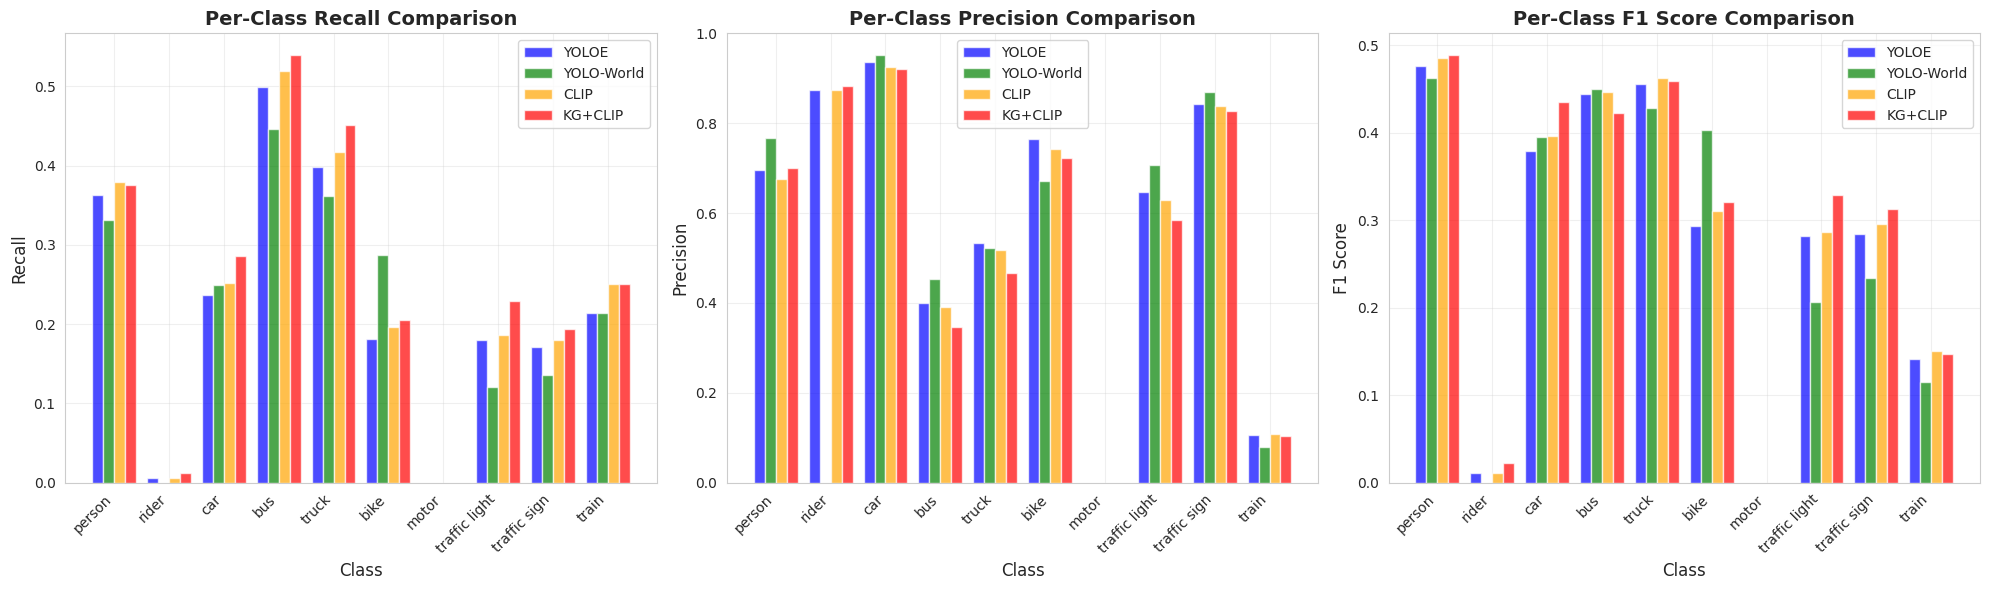

In [20]:
# 13. Visualization: Performance Comparison (with CLIP)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

x = np.arange(len(TARGET_CLASSES))
width = 0.2  

# Recall
recall_data = [
    per_class_yoloe["recall"].values,
    per_class_yoloworld["recall"].values,
    per_class_yoloe_clip["recall"].values,
    avg_per_class_kg_clip["recall"].values
]

axes[0].bar(x - 1.5*width, recall_data[0], width, label='YOLOE', color='blue', alpha=0.7)
axes[0].bar(x - 0.5*width, recall_data[1], width, label='YOLO-World', color='green', alpha=0.7)
axes[0].bar(x + 0.5*width, recall_data[2], width, label='CLIP', color='orange', alpha=0.7)
axes[0].bar(x + 1.5*width, recall_data[3], width, label='KG+CLIP', color='red', alpha=0.7)
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Recall', fontsize=12)
axes[0].set_title('Per-Class Recall Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(TARGET_CLASSES, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision
precision_data = [
    per_class_yoloe["precision"].values,
    per_class_yoloworld["precision"].values,
    per_class_yoloe_clip["precision"].values,
    avg_per_class_kg_clip["precision"].values
]

axes[1].bar(x - 1.5*width, precision_data[0], width, label='YOLOE', color='blue', alpha=0.7)
axes[1].bar(x - 0.5*width, precision_data[1], width, label='YOLO-World', color='green', alpha=0.7)
axes[1].bar(x + 0.5*width, precision_data[2], width, label='CLIP', color='orange', alpha=0.7)
axes[1].bar(x + 1.5*width, precision_data[3], width, label='KG+CLIP', color='red', alpha=0.7)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Per-Class Precision Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(TARGET_CLASSES, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1 Score
f1_data = [
    per_class_yoloe["f1"].values,
    per_class_yoloworld["f1"].values,
    per_class_yoloe_clip["f1"].values,
    avg_per_class_kg_clip["f1"].values
]

axes[2].bar(x - 1.5*width, f1_data[0], width, label='YOLOE', color='blue', alpha=0.7)
axes[2].bar(x - 0.5*width, f1_data[1], width, label='YOLO-World', color='green', alpha=0.7)
axes[2].bar(x + 0.5*width, f1_data[2], width, label='CLIP', color='orange', alpha=0.7)
axes[2].bar(x + 1.5*width, f1_data[3], width, label='KG+CLIP', color='red', alpha=0.7)
axes[2].set_xlabel('Class', fontsize=12)
axes[2].set_ylabel('F1 Score', fontsize=12)
axes[2].set_title('Per-Class F1 Score Comparison', fontsize=14, fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(TARGET_CLASSES, rotation=45, ha='right')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("per_class_comparison_with_clip.png", dpi=300, bbox_inches='tight')
plt.show()

# 14. Overall Performance Summary

In [21]:
# 14. Overall Performance Summary
summary_df = pd.DataFrame([
    {"Method": "YOLOE", **summary_yoloe},
    {"Method": "YOLO-World", **summary_yoloworld},
    {"Method": "YOLOE + CLIP", **summary_yoloe_clip},
    {"Method": "YOLOE + CLIP + KG (avg 3 runs)", **avg_summary_kg_clip}
])

summary_df = summary_df[["Method", "map50", "map50_95", "precision", "recall", "f1", "total_tp", "total_fp", "total_fn"]]
summary_df = summary_df.round(4)
display(summary_df)

,Method,map50,map50_95,precision,recall,f1,total_tp,total_fp,total_fn
0,YOLOE,0.3034,0.1697,0.8017,0.2294,0.3568,43797.0,10831.0,147091.0
1,YOLO-World,0.2712,0.1636,0.8456,0.2182,0.3469,41651.0,7606.0,149237.0
2,YOLOE + CLIP,0.3047,0.1710,0.7897,0.2419,0.3704,46181.0,12301.0,144707.0
3,YOLOE + CLIP + KG (avg 3 runs),0.3101,0.1715,0.7730,0.2694,0.3996,51432.0,15100.0,139456.0


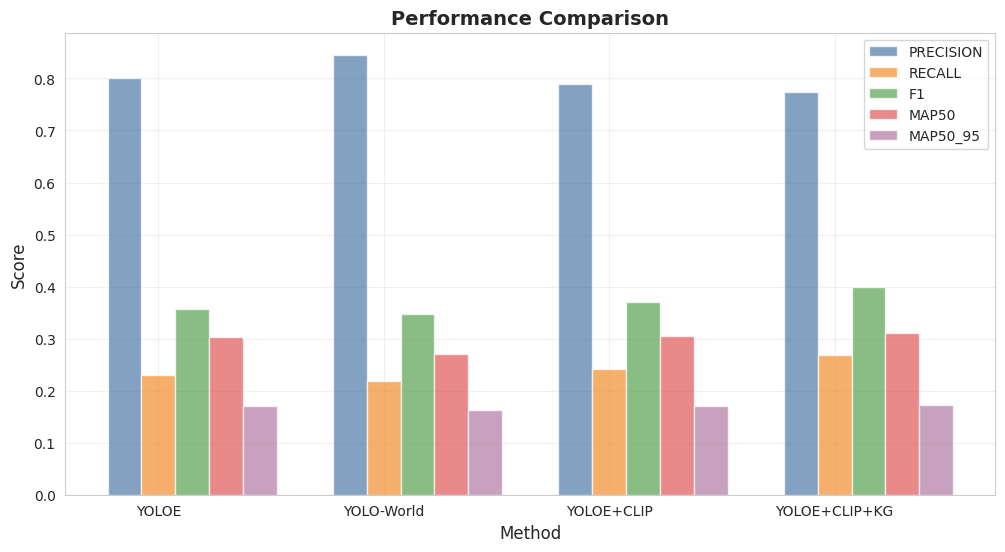

In [22]:
# Improvement Visualization
fig, axes = plt.subplots(1, 1, figsize=(12, 6))

methods = ["YOLOE", "YOLO-World", "YOLOE+CLIP", "YOLOE+CLIP+KG"]
metrics = ["precision","recall", "f1", "map50", "map50_95"]
colors_map = {
    "precision": "#4E79A7",   # xanh dương
    "recall":    "#F28E2B",   # cam
    "f1":        "#59A14F",   # xanh lá
    "map50":     "#E15759",   # đỏ
    "map50_95":  "#B07AA1"    # tím
}

x = np.arange(len(methods))
width = 0.15

for i, metric in enumerate(metrics):
    values = summary_df[metric].values
    axes.bar(x + i*width, values, width, label=metric.upper(), color=colors_map[metric], alpha=0.7)

axes.set_xlabel('Method', fontsize=12)
axes.set_ylabel('Score', fontsize=12)
axes.set_title('Performance Comparison', fontsize=14, fontweight='bold')
axes.set_xticks(x + width)
axes.set_xticklabels(methods)
axes.legend()
axes.grid(True, alpha=0.3)